### <center>Welcome to eJagruti!!!</center>
###### Model : Simple Linear Regression  DataSet: State Wise Wine Consumption and Population Owner: eJagruti

In [ ]:
# Importing the desired libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [225]:
# Import the Sample Dataset from csv having no header/label
df = pd.read_csv('State_Wine_Consumptions_and_Population.csv', header=None)
print(df.head(5))
print(len(df))

    0     1      2  3
0  ME  1171   2737  0
1  NH  1027   3353  0
2  VT   540   1977  0
3  MA  5835  19747  0
4  RI   975   3301  0
51


In [226]:
#assign label/header to each column
col_list=["state_postal_code","population(1000's)","wine_consumptions","wine_producer"]
df.columns=col_list
print(df.head(5))

  state_postal_code  population(1000's)  wine_consumptions  wine_producer
0                ME                1171               2737              0
1                NH                1027               3353              0
2                VT                 540               1977              0
3                MA                5835              19747              0
4                RI                 975               3301              0


In [227]:
#check the datatypes of each column
print(df.dtypes)

state_postal_code     object
population(1000's)     int64
wine_consumptions      int64
wine_producer          int64
dtype: object


In [228]:
#convert the datatype to desired datatype
df["state_postal_code"]=df["state_postal_code"].astype("string")
df["wine_producer"]=df["wine_producer"].astype("category")
print(df.dtypes)

state_postal_code       string
population(1000's)       int64
wine_consumptions        int64
wine_producer         category
dtype: object


In [229]:
#omit unwanted column which will not take part into the analysis
wdf=df.drop({"state_postal_code","wine_producer"},axis="columns")
print(wdf.head(5))

   population(1000's)  wine_consumptions
0                1171               2737
1                1027               3353
2                 540               1977
3                5835              19747
4                 975               3301


In [230]:
#check the correlation between dependent and independent variable
wdf.corr()

,population(1000's),wine_consumptions
population(1000's),1.00000,0.89827
wine_consumptions,0.89827,1.00000


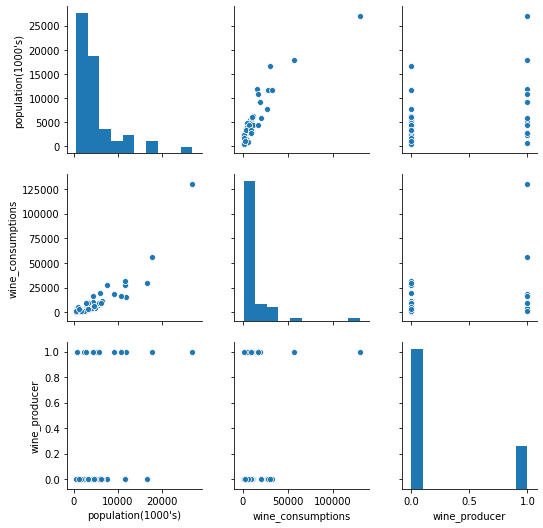

In [198]:
#visualize the data first
from matplotlib import pyplot
import seaborn as sns
sns.pairplot(df)

In [199]:
#identify the outliers in your data if any step by step

In [231]:
print(wdf.describe())

       population(1000's)  wine_consumptions
count           51.000000          51.000000
mean          4727.588235       11460.529412
std           5132.914779       19890.538834
min            507.000000         763.000000
25%           1117.500000        2371.500000
50%           3280.000000        5298.000000
75%           5650.500000       10704.000000
max          26997.000000      130159.000000


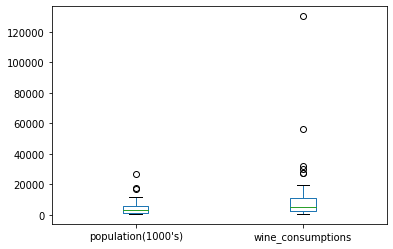

In [232]:
#draw the box plot for all the numerical data type to view outliers
wdf.plot(kind='box')
plt.show()

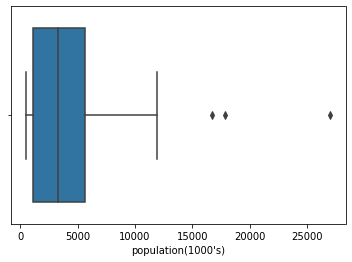

In [233]:
import seaborn as sns
sns.boxplot(x=wdf["population(1000's)"])

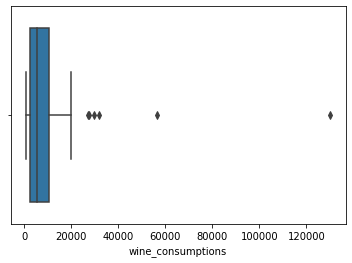

In [234]:
sns.boxplot(x=wdf["wine_consumptions"])

In [235]:
# skewness = 0 : normally distributed.
#skewness > 0 : more weight in the left tail of the distribution.
# skewness < 0 : more weight in the right tail of the distribution.

print(wdf['wine_consumptions'].skew())
print(wdf['wine_consumptions'].describe())

print(wdf["population(1000's)"].skew())
print(wdf["population(1000's)"].describe())
print(len(wdf))

4.67567582027847
count        51.000000
mean      11460.529412
std       19890.538834
min         763.000000
25%        2371.500000
50%        5298.000000
75%       10704.000000
max      130159.000000
Name: wine_consumptions, dtype: float64
2.3579111178456613
count       51.000000
mean      4727.588235
std       5132.914779
min        507.000000
25%       1117.500000
50%       3280.000000
75%       5650.500000
max      26997.000000
Name: population(1000's), dtype: float64
51


In [236]:
from scipy import stats
#print(stats.zscore(wdf)) #std dev away from mean
mdf=wdf[(np.abs(stats.zscore(wdf)) < 3).all(axis=1)]

print(mdf['wine_consumptions'].skew())
mdf['wine_consumptions'].describe()
print(mdf['wine_consumptions'].skew())
mdf['wine_consumptions'].describe()

print(mdf["population(1000's)"].skew())
mdf["population(1000's)"].describe()
print(mdf["population(1000's)"].skew())
mdf["population(1000's)"].describe()
print(mdf.head(5),len(mdf))

2.4625029502515177
2.4625029502515177
1.6916893278046572
1.6916893278046572
   population(1000's)  wine_consumptions
0                1171               2737
1                1027               3353
2                 540               1977
3                5835              19747
4                 975               3301 50


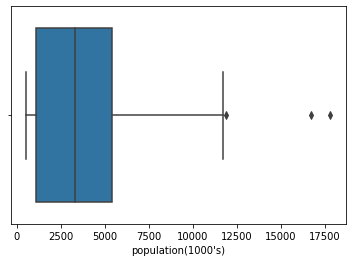

In [237]:
import seaborn as sns
sns.boxplot(x=mdf["population(1000's)"])

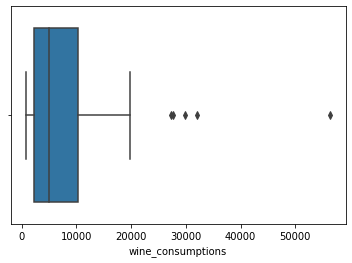

In [238]:
sns.boxplot(x=mdf["wine_consumptions"])

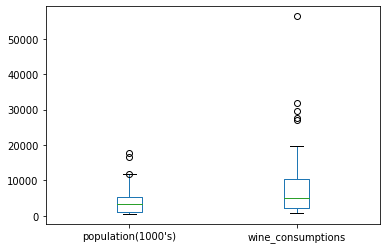

In [208]:
#draw the box plot for all the numerical data type to view outliers
mdf.plot(kind='box')
plt.show()

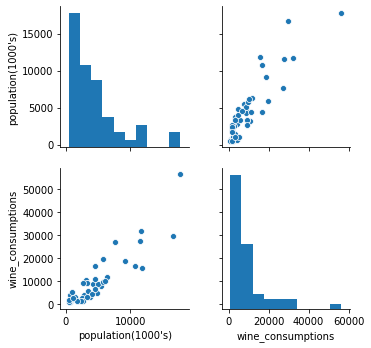

In [239]:
#understand overfitting
sns.pairplot(mdf)

In [240]:
#separate input variables and predicted variables
# X=mdf.iloc[:,0:1].values
# #print(X)
# y=mdf.iloc[:,1:2].values
# #print(y)
X=mdf["population(1000's)"].values.reshape(-1,1)
y=mdf["wine_consumptions"].values.reshape(-1,1)
# print(X)
# print(y)

In [241]:
import statsmodels.api as sm
X1 = sm.add_constant(X)
result = sm.OLS(y, X1).fit()  #ordinary least square regression
print(result.summary())
print(result.scale)
print("Standard Error Regression:",np.sqrt(result.scale))

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.813
Model:                            OLS   Adj. R-squared:                  0.809
Method:                 Least Squares   F-statistic:                     208.6
Date:                Tue, 15 Sep 2020   Prob (F-statistic):           4.25e-19
Time:                        08:22:12   Log-Likelihood:                -491.53
No. Observations:                  50   AIC:                             987.1
Df Residuals:                      48   BIC:                             990.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -883.1132    947.657     -0.932      0.3

In [242]:
#divide the data into train & test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.4, random_state = 0)
print(str(len(X_train))+"  "+str(len(X_test))+"  "+str(len(y_train))+ " "+str(len(y_test)))
print(str(X_train.shape)+"  "+str(X_test.shape)+"  "+str(y_train.shape)+ " "+str(y_test.shape))

30  20  30 20
(30, 1)  (20, 1)  (30, 1) (20, 1)


In [243]:
#Training the Simple Linear Regression model on the Training set
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
print(model)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)


In [244]:
print(model.coef_,model.intercept_)

[[2.24885712]] [-694.13650518]


In [245]:
#Given Input : X_train
#Model Predicted Output: model.predict(X_train)
#Actual Output :y_train
#Given Input : X_test
#Model Predicted Output: model.predict(X_test)
#Actual Output :y_test
#difference between actual output and model output shows the accuracy %
print('Train Score: ', model.score(X_train, y_train))  
print('Test Score: ', model.score(X_test, y_test)) 
print('Train Score: ', model.score(X_train, model.predict(X_train)))  
print('Test Score: ', model.score(X_test, model.predict(X_test)))

Train Score:  0.8048605955179534
Test Score:  0.8277644301792979
Train Score:  1.0
Test Score:  1.0


In [246]:
#This is the time to Test Your model whether he has properly learnt or not?
y_pred = model.predict(X_test)

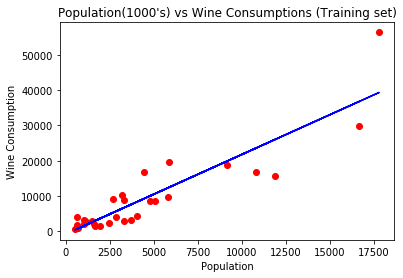

In [247]:
#Visualising the Training set results on scatter plot
plt.scatter(X_train, y_train, color = 'red')
plt.plot(X_train, model.predict(X_train), color = 'blue')
plt.title("Population(1000's) vs Wine Consumptions (Training set)")
plt.xlabel('Population')
plt.ylabel('Wine Consumption')
plt.show()

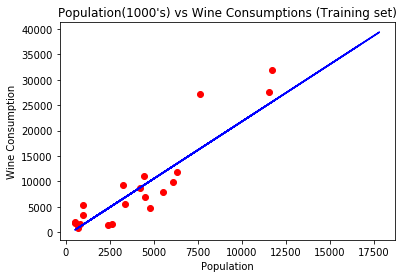

In [248]:
#visualising the Test Set Results
plt.scatter(X_test, y_test, color = 'red')
plt.plot(X_train, model.predict(X_train), color = 'blue')
plt.title("Population(1000's) vs Wine Consumptions (Training set)")
plt.xlabel('Population')
plt.ylabel('Wine Consumption')
plt.show()

In [249]:
op=model.predict([[1171]])
print(op)

[[1939.27518116]]


In [220]:
print(model.coef_,model.intercept_)
#y=b+mx


[[2.24885712]] [-694.13650518]


In [221]:
print(-535.23524627+2.29170111*(7000))

15506.67252373
